<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>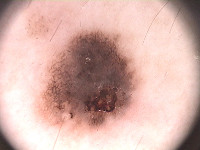</td><td>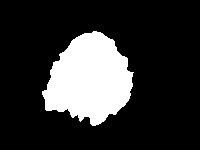</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [1]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=d402ac17-60ba-4dae-b23c-f254f174e065
To: /content/PH2Dataset.rar
100% 162M/162M [00:01<00:00, 143MB/s]


In [2]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [4]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [5]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

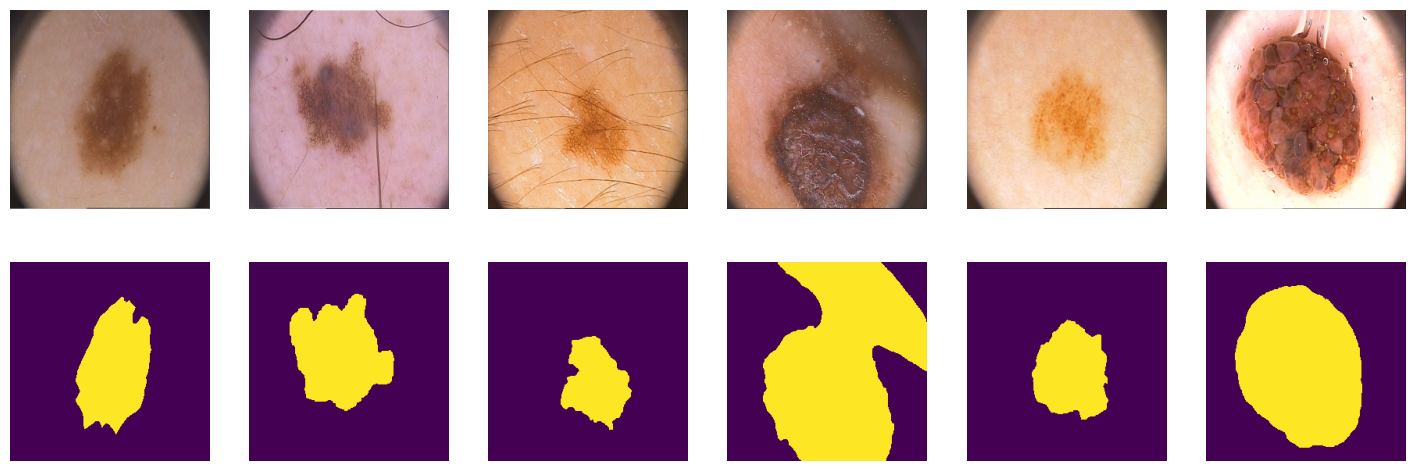

In [6]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [7]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [8]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [9]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [10]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [11]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.2 MB/s eta 0:00:00


In [12]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

In [14]:
bce_torch = nn.BCELoss(reduction='sum')
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [15]:
def bce_loss(y_pred, y_real):
    """
    Численно стабильная формула BCE:
    L = y_pred - y_real * y_pred + log(1 + exp(-y_pred))
    """
    loss = y_pred - y_real * y_pred + torch.log(1 + torch.exp(-y_pred))
    return loss.sum()

def bce_true(y_pred, y_real):
    """
    Честная прямая реализация BCE через sigmoid:
    L = -[y * log(sigmoid(y_pred)) + (1 - y) * log(1 - sigmoid(y_pred))]
    """
    sigmoid_pred = torch.sigmoid(y_pred)
    # Добавляем clamp для численной стабильности
    eps = 1e-7
    sigmoid_pred = torch.clamp(sigmoid_pred, eps, 1 - eps)
    loss = -(y_real * torch.log(sigmoid_pred) + (1 - y_real) * torch.log(1 - sigmoid_pred))
    return loss.sum()

Проверим корректность работы на простом примере

In [18]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true)}')



BCE loss from scratch bce_loss = 4.411546230316162
BCE loss честно посчитанный = 4.411546230316162
BCE loss from torch bce_torch = 4.411546230316162
BCE loss from torch with logits bce_torch = 4.411546230316162


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [19]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [20]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 14.907787322998047
BCE loss честно посчитанный               = 14.907787322998047
BCE loss from torch bce_torch             = 14.907787322998047
BCE loss from torch with logits bce_torch = 14.907787322998047


In [21]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [22]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 4.71MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 500kB/s]
Download completed


In [23]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

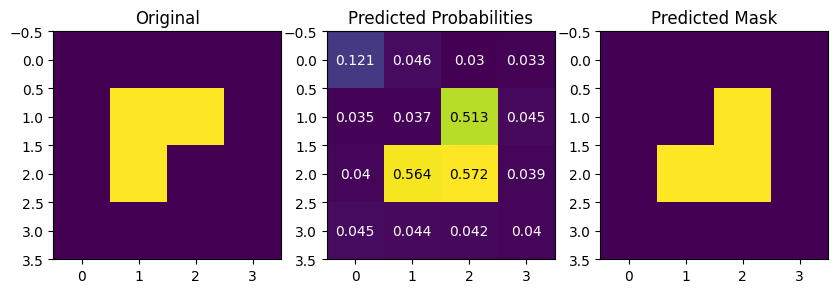

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [25]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

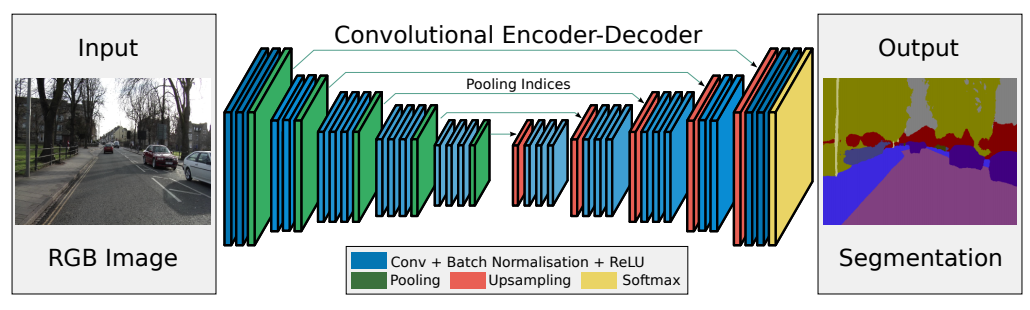

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [27]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.6MB/s]


In [28]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [29]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [30]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, is_last_block=False):
        super(DecoderBlock, self).__init__()
        self.unpool = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.layers = nn.ModuleList()
        self.is_last_block = is_last_block

        # Первые (depth-1) слоёв: каналы не меняются
        for i in range(depth - 1):
            self.layers.append(nn.Conv2d(in_channels=in_channels, out_channels=in_channels,
                                         kernel_size=kernel_size, padding=padding))
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.ReLU(inplace=True))

        # Последний конволюционный слой: меняет количество каналов
        self.layers.append(nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                                     kernel_size=kernel_size, padding=padding))

        # Если это не последний блок декодера, добавляем BN + ReLU
        if not is_last_block:
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, indices):
        x = self.unpool(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [31]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=64):
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)           # 3 -> 64
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)      # 64 -> 128
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)  # 128 -> 256
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)  # 256 -> 512

        # Encoder bottleneck
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3)  # 512 -> 512

        # Decoder bottleneck
        self.decoder0 = DecoderBlock(num_features * 8, num_features * 8, depth=3)  # 512 -> 512

        # Decoder
        self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3)  # 512 -> 256
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)  # 256 -> 128
        self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=2)      # 128 -> 64
        self.decoder4 = DecoderBlock(num_features, out_channels, depth=2, is_last_block=True)  # 64 -> 1

    def forward(self, x):
        # Encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)

        # Decoder
        x = self.decoder0(x, indices4)
        x = self.decoder1(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder3(x, indices1)
        output = self.decoder4(x, indices0)

        return output  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [32]:
from tqdm.notebook import tqdm
from torchmetrics import JaccardIndex

In [33]:
iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

In [34]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    num_batches = 0

    for images, masks in dataloader:
        images = images.float().to(device)
        masks = masks.float().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Вычисляем IoU
        preds = (torch.sigmoid(outputs) > 0.5).float()
        iou = iou_score(preds, masks.int())
        running_iou += iou.item()
        num_batches += 1

    return running_loss / num_batches, running_iou / num_batches


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    num_batches = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.float().to(device)
            masks = masks.float().to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            iou = iou_score(preds, masks.int())
            running_iou += iou.item()
            num_batches += 1

    return running_loss / num_batches, running_iou / num_batches


def train(model, train_dataloader, valid_dataloader, criterion, optimizer, device,
          num_epochs=50, scheduler=None, save_best=True):

    best_val_iou = 0.0
    train_losses = []
    val_losses = []
    train_ious = []
    val_ious = []

    for epoch in tqdm(range(num_epochs), desc="Training"):
        train_loss, train_iou = train_epoch(model, train_dataloader, criterion, optimizer, device)
        val_loss, val_iou = validate_epoch(model, valid_dataloader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_ious.append(train_iou)
        val_ious.append(val_iou)

        if scheduler is not None:
            scheduler.step(val_loss)

        if save_best and val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), 'best_model.pth')

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] '
                  f'Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}, '
                  f'Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}')

    # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(train_ious, label='Train IoU')
    ax2.plot(val_ious, label='Val IoU')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('IoU')
    ax2.set_title('IoU')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f'Best Validation IoU: {best_val_iou:.4f}')

    return train_losses, val_losses, train_ious, val_ious

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [ ]:
segnet_model = SegNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(segnet_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)

train_losses, val_losses, train_ious, val_ious = train(
    segnet_model, train_dataloader, valid_dataloader, criterion, optimizer, device,
    num_epochs=100, scheduler=scheduler
)

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch [1/100] Train Loss: 0.6499, Train IoU: 0.1884, Val Loss: 0.6775, Val IoU: 0.0000


## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [ ]:
def test(model, test_dataloader, criterion, device, checkpoint_path='best_model.pth', visualize=True):
    # Загружаем лучший чекпоинт
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()

    running_loss = 0.0
    running_iou = 0.0
    num_batches = 0

    all_images = []
    all_masks = []
    all_preds = []

    with torch.no_grad():
        for images, masks in test_dataloader:
            images = images.float().to(device)
            masks = masks.float().to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            iou = iou_score(preds, masks.int())
            running_iou += iou.item()
            num_batches += 1

            all_images.append(images.cpu())
            all_masks.append(masks.cpu())
            all_preds.append(preds.cpu())

    avg_loss = running_loss / num_batches
    avg_iou = running_iou / num_batches

    print(f'Test Loss: {avg_loss:.4f}, Test IoU: {avg_iou:.4f}')

    # Визуализация
    if visualize:
        all_images = torch.cat(all_images, dim=0)
        all_masks = torch.cat(all_masks, dim=0)
        all_preds = torch.cat(all_preds, dim=0)

        num_show = min(6, len(all_images))
        fig, axes = plt.subplots(3, num_show, figsize=(3 * num_show, 9))

        for i in range(num_show):
            # Исходное изображение
            axes[0, i].imshow(np.rollaxis(all_images[i].numpy(), 0, 3))
            axes[0, i].set_title('Image')
            axes[0, i].axis('off')

            # Ground truth маска
            axes[1, i].imshow(all_masks[i].squeeze(0).numpy(), cmap='gray')
            axes[1, i].set_title('Ground Truth')
            axes[1, i].axis('off')

            # Предсказание модели
            axes[2, i].imshow(all_preds[i].squeeze(0).numpy(), cmap='gray')
            axes[2, i].set_title('Prediction')
            axes[2, i].axis('off')

        plt.tight_layout()
        plt.show()

    return avg_loss, avg_iou

In [ ]:
test(segnet_model, test_dataloader, criterion, device, checkpoint_path='best_model.pth')

# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [ ]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    """
    Это именно метрика, не лосс.
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    labels = labels.float()

    intersection = (preds * labels).sum()
    union = preds.sum() + labels.sum()

    eps = 1e-8
    score = (2.0 * intersection + eps) / (union + eps)

    return score




Проверим на корректность функцию dice_score:

In [ ]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)

assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.6667)

In [ ]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)

'''

In [ ]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [ ]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
    """
    Это лосс. Дифференцируемый - работаем с вероятностями, а не с бинарными масками.
    """
    probs = torch.sigmoid(logits)
    labels = labels.float()

    intersection = (probs * labels).sum()
    union = probs.sum() + labels.sum()

    eps = 1e-8
    dice = (2.0 * intersection + eps) / (union + eps)

    loss = 1.0 - dice

    return loss

Проверка на корректность:

In [ ]:
# проверьте, что у вас установлена библиотека
#!pip install segmentation-models-pytorch

In [ ]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')

assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

In [ ]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [ ]:
def focal_loss(logits: torch.Tensor, labels: torch.Tensor, alpha: float = 0.25, gamma: float = 2.0):
    """
    Focal Loss для бинарной сегментации.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    где p_t = p если y=1, иначе p_t = 1-p
    """
    labels = labels.float()

    # Численно стабильный BCE
    bce = F.binary_cross_entropy_with_logits(logits, labels, reduction='none')

    # Вероятности
    probs = torch.sigmoid(logits)
    p_t = probs * labels + (1 - probs) * (1 - labels)

    # alpha weighting
    alpha_t = alpha * labels + (1 - alpha) * (1 - labels)

    # Focal weight
    focal_weight = alpha_t * (1 - p_t) ** gamma

    loss = focal_weight * bce

    return loss.sum()

Проверка корректности функции:

In [ ]:
from segmentation_models_pytorch.losses import FocalLoss
focal_loss_torch = FocalLoss(mode='binary', alpha=0.25, gamma=2.0)

# Сравнение (FocalLoss из smp может использовать mean reduction, поэтому сравним normalized)
my_focal = focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=0.25, gamma=2.0)
print(f"My focal loss: {my_focal}")

In [ ]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [ ]:
# BCE Loss
segnet_bce = SegNet().to(device)
optimizer_bce = optim.Adam(segnet_bce.parameters(), lr=1e-3)
scheduler_bce = optim.lr_scheduler.ReduceLROnPlateau(optimizer_bce, mode='min', patience=10, factor=0.5)
criterion_bce = nn.BCEWithLogitsLoss()

print("=== Training SegNet with BCE Loss ===")
bce_results = train(segnet_bce, train_dataloader, valid_dataloader, criterion_bce,
                    optimizer_bce, device, num_epochs=100, scheduler=scheduler_bce)

# Dice Loss
segnet_dice = SegNet().to(device)
optimizer_dice = optim.Adam(segnet_dice.parameters(), lr=1e-3)
scheduler_dice = optim.lr_scheduler.ReduceLROnPlateau(optimizer_dice, mode='min', patience=10, factor=0.5)

print("=== Training SegNet with Dice Loss ===")
dice_results = train(segnet_dice, train_dataloader, valid_dataloader, dice_loss,
                     optimizer_dice, device, num_epochs=100, scheduler=scheduler_dice)

# Focal Loss (обёртка для совместимости с train)
class FocalLossWrapper(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, labels):
        return focal_loss(logits, labels, self.alpha, self.gamma)

segnet_focal = SegNet().to(device)
optimizer_focal = optim.Adam(segnet_focal.parameters(), lr=1e-3)
scheduler_focal = optim.lr_scheduler.ReduceLROnPlateau(optimizer_focal, mode='min', patience=10, factor=0.5)
criterion_focal = FocalLossWrapper()

print("=== Training SegNet with Focal Loss ===")
focal_results = train(segnet_focal, train_dataloader, valid_dataloader, criterion_focal,
                      optimizer_focal, device, num_epochs=100, scheduler=scheduler_focal)

In [ ]:
print("=== Test Results ===")
print("\nSegNet + BCE Loss:")
test(segnet_bce, test_dataloader, criterion_bce, device, checkpoint_path='best_model.pth')

print("\nSegNet + Dice Loss:")
# Нужно сохранять чекпоинты с разными именами - модифицируем train для этого
# Для простоты тестируем последнюю модель
test(segnet_dice, test_dataloader, dice_loss, device)

print("\nSegNet + Focal Loss:")
test(segnet_focal, test_dataloader, criterion_focal, device)

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

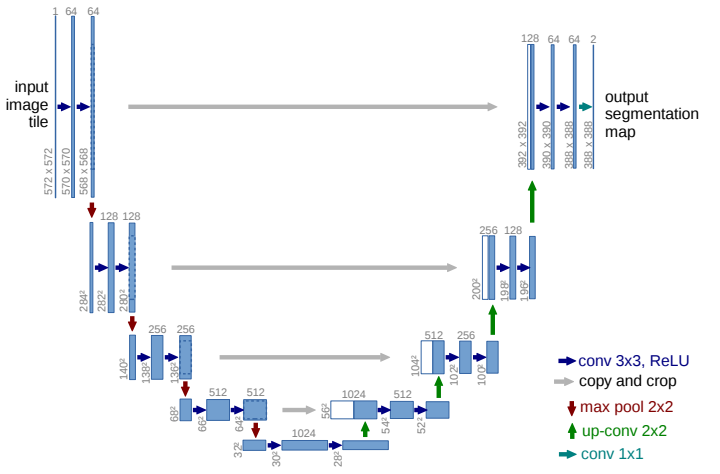

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [ ]:
class UNetEncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        conv_out = self.conv(x)
        pooled = self.pool(conv_out)
        return pooled, conv_out  # возвращаем и pooled, и conv_out для skip connection


class UNetDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Транспонированная свёртка для upsampling
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        # После конкатенации со skip connection каналов будет out_channels * 2
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels * 2, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.upconv(x)
        # Конкатенация по каналам (skip connection)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


class UNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()

        # Encoder
        self.encoder1 = UNetEncoderBlock(3, 64)
        self.encoder2 = UNetEncoderBlock(64, 128)
        self.encoder3 = UNetEncoderBlock(128, 256)
        self.encoder4 = UNetEncoderBlock(256, 512)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
        )

        # Decoder
        self.decoder4 = UNetDecoderBlock(1024, 512)
        self.decoder3 = UNetDecoderBlock(512, 256)
        self.decoder2 = UNetDecoderBlock(256, 128)
        self.decoder1 = UNetDecoderBlock(128, 64)

        # Final convolution
        self.final_conv = nn.Conv2d(64, n_class, kernel_size=1)

    def forward(self, x):
        # Encoder
        x, skip1 = self.encoder1(x)   # skip1: 64 channels
        x, skip2 = self.encoder2(x)   # skip2: 128 channels
        x, skip3 = self.encoder3(x)   # skip3: 256 channels
        x, skip4 = self.encoder4(x)   # skip4: 512 channels

        # Bottleneck
        x = self.bottleneck(x)        # 1024 channels

        # Decoder with skip connections
        x = self.decoder4(x, skip4)   # 512 channels
        x = self.decoder3(x, skip3)   # 256 channels
        x = self.decoder2(x, skip2)   # 128 channels
        x = self.decoder1(x, skip1)   # 64 channels

        # Final 1x1 convolution
        output = self.final_conv(x)   # n_class channels

        return output  # no activation

In [ ]:
unet_model = UNet().to(device)

# Для корректного сравнения модифицируем функцию train, чтобы сохранять чекпоинты с разными именами
def train_with_name(model, train_dl, valid_dl, criterion, optimizer, device,
                    num_epochs=100, scheduler=None, model_name='model'):

    best_val_iou = 0.0
    train_losses, val_losses, train_ious, val_ious = [], [], [], []

    for epoch in tqdm(range(num_epochs), desc=f"Training {model_name}"):
        train_loss, train_iou = train_epoch(model, train_dl, criterion, optimizer, device)
        val_loss, val_iou = validate_epoch(model, valid_dl, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_ious.append(train_iou)
        val_ious.append(val_iou)

        if scheduler is not None:
            scheduler.step(val_loss)

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), f'best_{model_name}.pth')

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] '
                  f'Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}, '
                  f'Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}')

    # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{model_name} Loss')
    ax1.legend()

    ax2.plot(train_ious, label='Train IoU')
    ax2.plot(val_ious, label='Val IoU')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('IoU')
    ax2.set_title(f'{model_name} IoU')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f'Best Validation IoU for {model_name}: {best_val_iou:.4f}')
    return train_losses, val_losses, train_ious, val_ious

# UNet + BCE
unet_bce = UNet().to(device)
optimizer_unet_bce = optim.Adam(unet_bce.parameters(), lr=1e-3)
scheduler_unet_bce = optim.lr_scheduler.ReduceLROnPlateau(optimizer_unet_bce, mode='min', patience=10, factor=0.5)

print("=== UNet + BCE Loss ===")
unet_bce_results = train_with_name(unet_bce, train_dataloader, valid_dataloader,
                                    criterion_bce, optimizer_unet_bce, device,
                                    num_epochs=100, scheduler=scheduler_unet_bce,
                                    model_name='unet_bce')

# UNet + Dice
unet_dice = UNet().to(device)
optimizer_unet_dice = optim.Adam(unet_dice.parameters(), lr=1e-3)
scheduler_unet_dice = optim.lr_scheduler.ReduceLROnPlateau(optimizer_unet_dice, mode='min', patience=10, factor=0.5)

print("=== UNet + Dice Loss ===")
unet_dice_results = train_with_name(unet_dice, train_dataloader, valid_dataloader,
                                     dice_loss, optimizer_unet_dice, device,
                                     num_epochs=100, scheduler=scheduler_unet_dice,
                                     model_name='unet_dice')

# UNet + Focal
unet_focal = UNet().to(device)
optimizer_unet_focal = optim.Adam(unet_focal.parameters(), lr=1e-3)
scheduler_unet_focal = optim.lr_scheduler.ReduceLROnPlateau(optimizer_unet_focal, mode='min', patience=10, factor=0.5)

print("=== UNet + Focal Loss ===")
unet_focal_results = train_with_name(unet_focal, train_dataloader, valid_dataloader,
                                      criterion_focal, optimizer_unet_focal, device,
                                      num_epochs=100, scheduler=scheduler_unet_focal,
                                      model_name='unet_focal')

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.

